# Imports

In [1]:
import numpy as np
import numpy.typing as npt
from PIL import Image

import graph_wedgelets.image as GWI

# Image examples

## Example 1

In [2]:
with Image.open("img/michael-kyule-etgNEj4M5Ew-unsplash.jpg") as im:
    nodes, signal, width, height = GWI.to_signal(im)

In [3]:
BWP: GWI.BinaryWedgePartitioningTree = GWI.BinaryWedgePartitioningTree(
    nodes, signal, 1, 3 * max([nodes.width, nodes.height])
)

In [4]:
BWP.wedgelet_encode(signal, method="RA", method_parameter=16, tolerance=1e-1)

In [5]:
BWP.partition_size

2880

In [6]:
BWP.save_npz("npz/young-people.npz")

In [7]:
new_signal: npt.NDArray[np.floating] = GWI.BWPDecoder(**BWP.export()).wedgelet_decode()[
    0
]

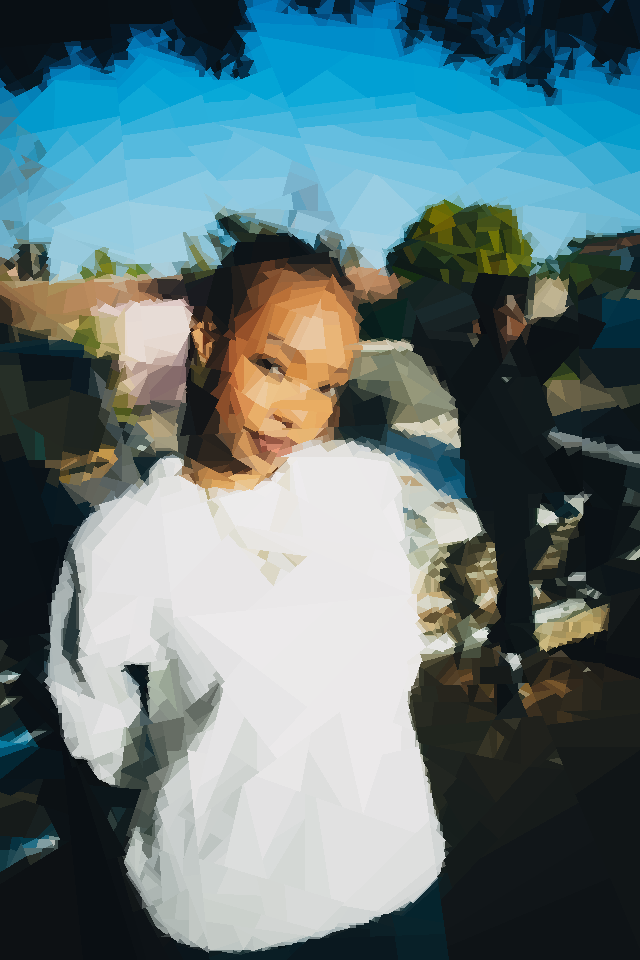

In [8]:
Image.fromarray(GWI.from_signal(new_signal, width, height).astype(np.uint8))

## Example 2

In [9]:
with Image.open("img/eduard-pretsi-mu9NgVgJeTM-unsplash.jpg") as im:
    nodes, signal, width, height = GWI.to_signal(im)

In [10]:
BWP: GWI.BinaryWedgePartitioningTree = GWI.BinaryWedgePartitioningTree(
    nodes, signal, 1, 3 * max([nodes.width, nodes.height])
)

In [11]:
BWP.wedgelet_encode(signal, method="RA", method_parameter=16, tolerance=1e-1)

In [12]:
BWP.partition_size

1920

In [13]:
BWP.save_npz("npz/big-ben.npz")

In [14]:
new_signal: npt.NDArray[np.floating] = GWI.BWPDecoder(**BWP.export()).wedgelet_decode()[0]

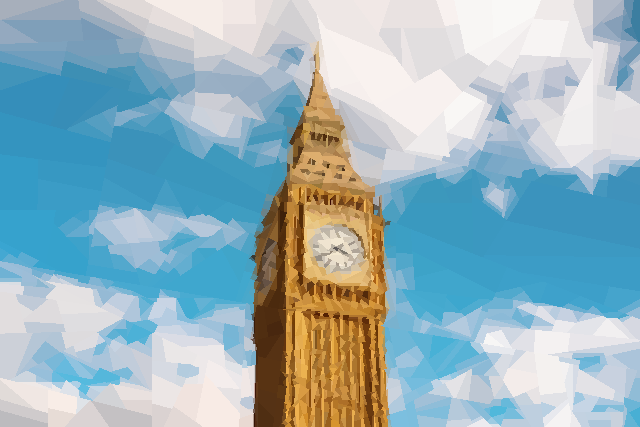

In [15]:
Image.fromarray(GWI.from_signal(new_signal, width, height).astype(np.uint8))

# Graph example

In [16]:
import igraph as ig
import graph_wedgelets.graph as GBF

In [17]:
malta: ig.Graph = ig.Graph.Read("graph/malta.gml")

In [18]:
signal: npt.NDArray = np.load("npz/malta_signal.npz")["arr_0"]

In [ ]:
BWP: GBF.BinaryWedgePartitioningTree = GBF.BinaryWedgePartitioningTree(
    malta, signal, len(malta.vs), initial_partition_method="betweenness"
)